In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns


# Cargar los datasets
visits = pd.read_csv('visits_log_us.csv')
orders = pd.read_csv('orders_log_us.csv')
costs = pd.read_csv('costs_us.csv')



In [24]:



# Optimizar los tipos de datos (conversión de fechas)

visits.columns = visits.columns.str.lower().str.replace(' ', '_')
orders.columns = orders.columns.str.lower().str.replace(' ', '_')
costs.columns = costs.columns.str.lower().str.replace(' ', '_')





In [25]:

# 3. CORRECCIÓN: Convertir a datetime antes de cualquier operación temporal
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])


In [26]:

# --- VISITAS ---
# Crear columnas de tiempo para agregación
visits['session_year']  = visits['start_ts'].dt.year
visits['session_month'] = visits['start_ts'].dt.to_period('M')
visits['session_week']  = visits['start_ts'].dt.to_period('W')
visits['session_date']  = visits['start_ts'].dt.date



In [27]:
print("--- INFORME DE VISITAS ---")

# 1. Usuarios activos (DAU, WAU, MAU)
dau = visits.groupby('session_date').agg({'uid': 'nunique'}).mean().iloc[0]
wau = visits.groupby('session_week').agg({'uid': 'nunique'}).mean().iloc[0]
mau = visits.groupby('session_month').agg({'uid': 'nunique'}).mean().iloc[0]

print(f"DAU (Usuarios únicos por día promedio): {dau:.2f}")
print(f"WAU (Usuarios únicos por semana promedio): {wau:.2f}")
print(f"MAU (Usuarios únicos por mes promedio): {mau:.2f}\n")


--- INFORME DE VISITAS ---
DAU (Usuarios únicos por día promedio): 907.99
WAU (Usuarios únicos por semana promedio): 5716.25
MAU (Usuarios únicos por mes promedio): 23228.42



In [28]:

# 2. Número de sesiones por día (Un usuario puede tener más de una)
sessions_per_day = visits.groupby('session_date').agg({'uid': 'count'}).mean().iloc[0]
print(f"Número total de sesiones promedio por día: {sessions_per_day:.2f}")

# Promedio de sesiones diarias por usuario activo
sessions_per_user = visits.groupby('session_date').agg({'uid': ['count', 'nunique']})
sessions_per_user.columns = ['n_sessions', 'n_users']
sessions_per_user['sessions_per_user'] = sessions_per_user['n_sessions'] / sessions_per_user['n_users']
print(f"Sesiones diarias promedio por usuario activo: {sessions_per_user['sessions_per_user'].mean():.2f}\n")

Número total de sesiones promedio por día: 987.36
Sesiones diarias promedio por usuario activo: 1.08



In [29]:

# 3. Duración de cada sesión (ASL)
visits['duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()
asl_mode = visits['duration_sec'].mode()[0]
print(f"Duración típica de una sesión (Moda): {asl_mode} segundos\n")


Duración típica de una sesión (Moda): 60.0 segundos



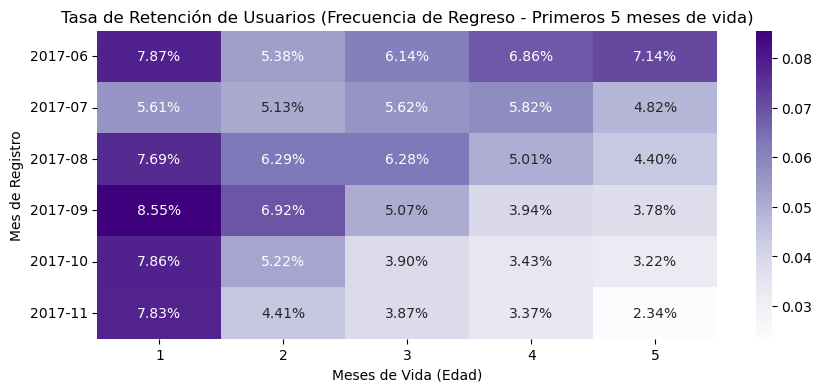

In [30]:

# --- VENTAS ---
''' 1. Tiempo transcurrido para la conversión
# Encontrar la primera visita de cada usuario
first_visits = visits.groupby('uid').agg({'start_ts': 'min'}).reset_index()
first_visits.columns = ['uid', 'first_visit'] '''

# 4. CORRECCIÓN: Frecuencia de regreso (Tasa de Retención por Cohorte de Registro)
user_first_visit = visits.groupby('uid').agg({'session_month': 'min'}).reset_index()
user_first_visit.columns = ['uid', 'first_visit_month']

visits_cohorts = pd.merge(visits, user_first_visit, on='uid')
visits_cohorts['cohort_age'] = (visits_cohorts['session_month'] - visits_cohorts['first_visit_month']).apply(lambda x: x.n)

retention_pivot = visits_cohorts.pivot_table(
    index='first_visit_month', columns='cohort_age', values='uid', aggfunc='nunique'
)
retention_rate = retention_pivot.divide(retention_pivot.iloc[:, 0], axis=0)

# Gráfico de Retención
plt.figure(figsize=(10, 4))
sns.heatmap(retention_rate.iloc[:6, 1:6], annot=True, fmt='.2%', cmap='Purples')
plt.title('Tasa de Retención de Usuarios (Frecuencia de Regreso - Primeros 5 meses de vida)')
plt.ylabel('Mes de Registro')
plt.xlabel('Meses de Vida (Edad)')
plt.show()



In [31]:

# PASO 3. INFORME DE VENTAS (NEGOCIO)
# ==========================================

print("\n--- INFORME DE VENTAS ---")

# 1. Mapear el perfil inicial de adquisición del usuario (fuente y dispositivo de su primera sesión)
user_profile = visits.sort_values('start_ts').groupby('uid').first().reset_index()[['uid', 'source_id', 'device']]

# Encontrar la primera visita y primera compra
first_visits = visits.groupby('uid').agg({'start_ts': 'min'}).reset_index().rename(columns={'start_ts': 'first_visit'})
first_orders = orders.groupby('uid').agg({'buy_ts': 'min'}).reset_index().rename(columns={'buy_ts': 'first_order'})

# Tiempo transcurrido para la conversión
conversion_df = pd.merge(first_visits, first_orders, on='uid', how='inner')
conversion_df['days_to_convert'] = (conversion_df['first_order'] - conversion_df['first_visit']).dt.days



--- INFORME DE VENTAS ---


In [32]:
def classify_conversion(days):
    if days == 0: return 'Conversion 0d'
    elif days == 1: return 'Conversion 1d'
    elif days <= 7: return 'Conversion 2-7d'
    else: return 'Conversion 8d+'

conversion_df['conversion_cohort'] = conversion_df['days_to_convert'].apply(classify_conversion)
print("Distribución de la velocidad de conversión global:")
print(conversion_df['conversion_cohort'].value_counts(normalize=True).round(4) * 100, "\n")

Distribución de la velocidad de conversión global:
conversion_cohort
Conversion 0d      72.18
Conversion 8d+     19.39
Conversion 2-7d     5.66
Conversion 1d       2.77
Name: proportion, dtype: float64 



In [33]:
# CORRECCIÓN: Velocidad de conversión segmentada por Fuente y Dispositivo
conversion_extended = pd.merge(conversion_df, user_profile, on='uid', how='inner')
print("Mediana de días para convertir por Dispositivo:")
print(conversion_extended.groupby('device')['days_to_convert'].median(), "\n")

Mediana de días para convertir por Dispositivo:
device
desktop    0.0
touch      0.0
Name: days_to_convert, dtype: float64 



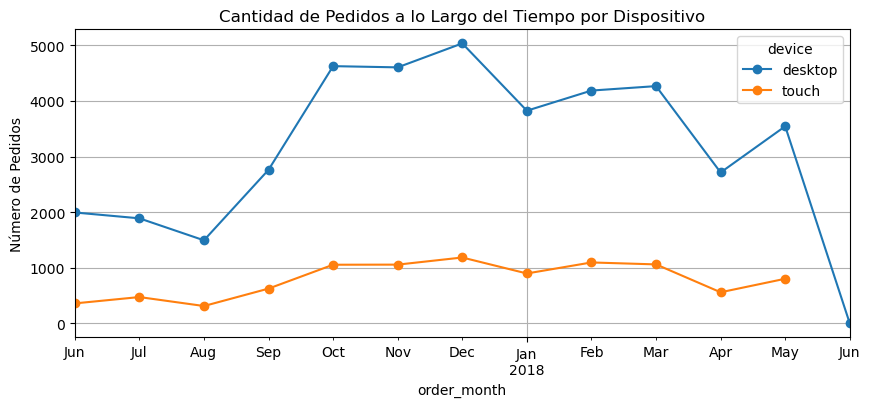

In [35]:
# 2. CORRECCIÓN: Cantidad de pedidos realizados en un período dado (Evolución temporal segmentada)
orders_extended = pd.merge(orders, user_profile, on='uid', how='inner')
orders_extended['order_month'] = orders_extended['buy_ts'].dt.to_period('M')

orders_by_period = orders_extended.pivot_table(index='order_month', columns='device', values='uid', aggfunc='count')
orders_by_period.plot(kind='line', marker='o', figsize=(10, 4))
plt.title('Cantidad de Pedidos a lo Largo del Tiempo por Dispositivo')
plt.ylabel('Número de Pedidos')
plt.grid(True)
plt.show()


Tamaño promedio de compra global: $5.00


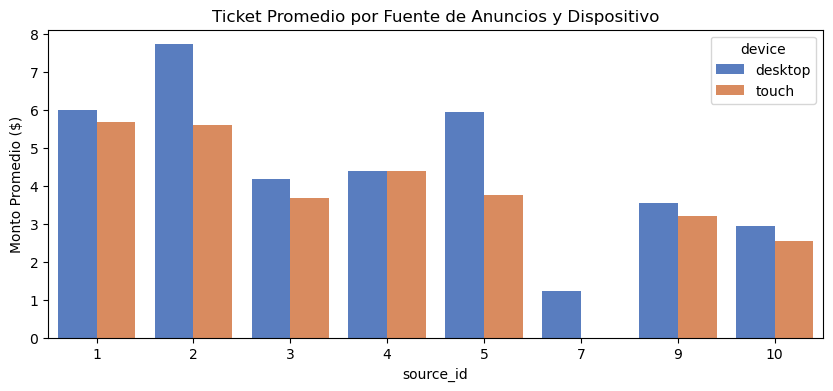

In [36]:

# 3. Tamaño promedio de compra (Ticket promedio) global y segmentado
ticket_promedio = orders['revenue'].mean()
print(f"Tamaño promedio de compra global: ${ticket_promedio:.2f}")

ticket_segmented = orders_extended.groupby(['device', 'source_id']).agg({'revenue': 'mean'}).reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(data=ticket_segmented, x='source_id', y='revenue', hue='device', palette='muted')
plt.title('Ticket Promedio por Fuente de Anuncios y Dispositivo')
plt.ylabel('Monto Promedio ($)')
plt.show()

In [38]:
# PASO 4. ANÁLISIS DE COHORTES Y MARKETING (LTV, CAC, ROMI POR FUENTE)
# ==========================================

print("\n--- INFORME DE MARKETING (MÉTRICAS POR FUENTE) ---")

buyer_first_order = orders_extended.groupby('uid').agg({'buy_ts': 'min'}).reset_index()

# Forzamos la conversión a datetime puro para limpiar cualquier residuo del notebook
buyer_first_order['buy_ts'] = pd.to_datetime(buyer_first_order['buy_ts'])
buyer_first_order['cohort_month'] = buyer_first_order['buy_ts'].dt.to_period('M')
print(buyer_first_order.head())


--- INFORME DE MARKETING (MÉTRICAS POR FUENTE) ---
                uid              buy_ts cohort_month
0   313578113262317 2018-01-03 21:51:00      2018-01
1  1575281904278712 2017-06-03 10:13:00      2017-06
2  2429014661409475 2017-10-11 18:33:00      2017-10
3  2464366381792757 2018-01-28 15:54:00      2018-01
4  2551852515556206 2017-11-24 10:14:00      2017-11


In [40]:
# Asociar a cada comprador su fuente de adquisición inicial fija
buyer_profile = pd.merge(buyer_first_order[['uid', 'cohort_month']], user_profile, on='uid', how='inner')

# Asegurar que orders_extended tenga también la columna order_month limpia
orders_extended['buy_ts'] = pd.to_datetime(orders_extended['buy_ts'])
orders_extended['order_month'] = orders_extended['buy_ts'].dt.to_period('M')

print("🚀 Transformación de periodos completada de forma segura.")

🚀 Transformación de periodos completada de forma segura.


In [41]:
# Unir el histórico de órdenes con las cohortes de origen correctas de los compradores
orders_with_cohorts = pd.merge(orders_extended[['uid', 'order_month', 'revenue']], buyer_profile, on='uid', how='inner')

# CORRECCIÓN DE DENOMINADOR: Contar COMPRADORES ÚNICOS REALES de la cohorte por su fuente original
cohort_sizes = orders_with_cohorts.groupby(['cohort_month', 'source_id']).agg({'uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['cohort_month', 'source_id', 'n_buyers']

In [42]:
# Calcular ingresos mensuales acumulados por cohorte y fuente
cohort_revenue = orders_with_cohorts.groupby(['cohort_month', 'order_month', 'source_id']).agg({'revenue': 'sum'}).reset_index()

# Unir ingresos con tamaños de cohorte
ltv_base = pd.merge(cohort_revenue, cohort_sizes, on=['cohort_month', 'source_id'])

In [43]:
ltv_base['age'] = (
    (ltv_base['order_month'].dt.year - ltv_base['cohort_month'].dt.year) * 12 + 
    (ltv_base['order_month'].dt.month - ltv_base['cohort_month'].dt.month)
).astype(int)

# Calcular LTV Bruto del mes por comprador
ltv_base['ltv_month'] = ltv_base['revenue'] / ltv_base['n_buyers']

# Ordenar y acumular el LTV cronológicamente por edad del cliente
ltv_base = ltv_base.sort_values(['cohort_month', 'source_id', 'age'])
ltv_base['ltv_cumulative'] = ltv_base.groupby(['cohort_month', 'source_id'])['ltv_month'].cumsum()


In [45]:
# 2. GASTOS DE MARKETING EN EL TIEMPO POR FUENTE
costs['dt'] = pd.to_datetime(costs['dt']) # Asegurar tipo limpio

costs['cost_month'] = costs['dt'].dt.to_period('M')

monthly_costs = costs.groupby(['cost_month', 'source_id']).agg({'costs': 'sum'}).reset_index()
print("🚀 Gastos agrupados por mes de forma correcta.")

🚀 Gastos agrupados por mes de forma correcta.


In [46]:
# 3. CORRECCIÓN DE CAC POR FUENTE: Unimos costos del mes con nuevos compradores reales de ese mismo mes y fuente
cac_df = pd.merge(cohort_sizes, monthly_costs, left_on=['cohort_month', 'source_id'], right_on=['cost_month', 'source_id'], how='inner')
cac_df['cac'] = cac_df['costs'] / cac_df['n_buyers']

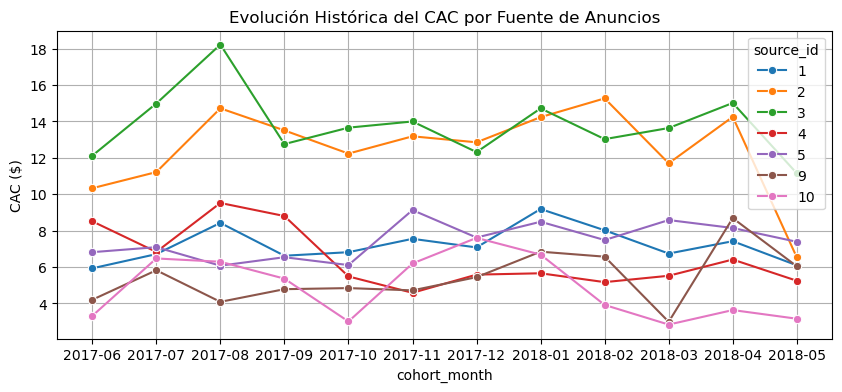

In [48]:
# Graficar evolución del CAC por fuente 
plt.figure(figsize=(10, 4))
cac_df_plot = cac_df.copy()
cac_df_plot['cohort_month'] = cac_df_plot['cohort_month'].astype(str)

sns.lineplot(data=cac_df_plot, x='cohort_month', y='cac', hue='source_id', marker='o', palette='tab10')
plt.title('Evolución Histórica del CAC por Fuente de Anuncios')
plt.ylabel('CAC ($)')
plt.grid(True)
plt.show()

In [49]:
# 4. CORRECCIÓN DE ROMI POR FUENTE
romi_master = pd.merge(ltv_base, cac_df[['cohort_month', 'source_id', 'cac']], on=['cohort_month', 'source_id'])
romi_master['romi'] = romi_master['ltv_cumulative'] / romi_master['cac']

C:\Users\Bloos\AppData\Local\Temp\ipykernel_33996\2762226347.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=romi_age_5, x='source_id', y='romi', palette='viridis')


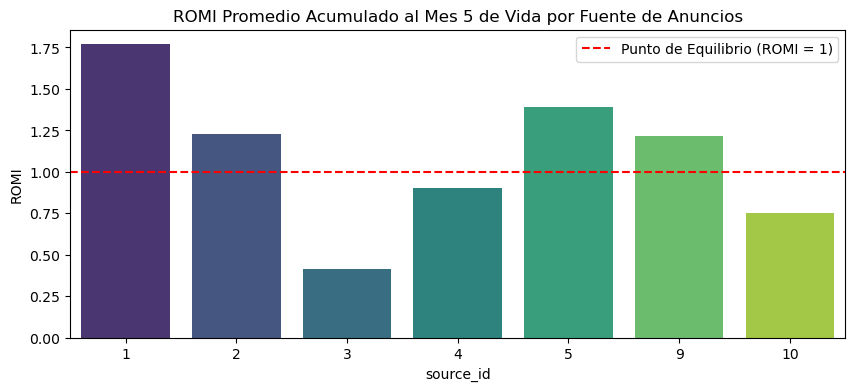

Métricas de rendimiento por Fuente de Anuncios en su Mes 5 de ciclo de vida:
   source_id  romi    cac
0          1  1.77   7.01
1          2  1.23  12.58
2          3  0.41  14.01
3          4  0.90   7.04
4          5  1.39   7.05
5          9  1.22   4.84
6         10  0.75   5.60


In [50]:
# 4. CORRECCIÓN DE ROMI POR FUENTE
romi_master = pd.merge(ltv_base, cac_df[['cohort_month', 'source_id', 'cac']], on=['cohort_month', 'source_id'], how='inner')
romi_master['romi'] = romi_master['ltv_cumulative'] / romi_master['cac']

# Resumen de rentabilidad final por fuente al Mes 5 de vida (Edad 5)
romi_age_5 = romi_master[romi_master['age'] == 5].groupby('source_id').agg({'romi': 'mean', 'cac': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(data=romi_age_5, x='source_id', y='romi', palette='viridis')
plt.axhline(1.0, color='red', linestyle='--', label='Punto de Equilibrio (ROMI = 1)')
plt.title('ROMI Promedio Acumulado al Mes 5 de Vida por Fuente de Anuncios')
plt.ylabel('ROMI')
plt.legend()
plt.show()

print("Métricas de rendimiento por Fuente de Anuncios en su Mes 5 de ciclo de vida:")
print(romi_age_5.round(2))


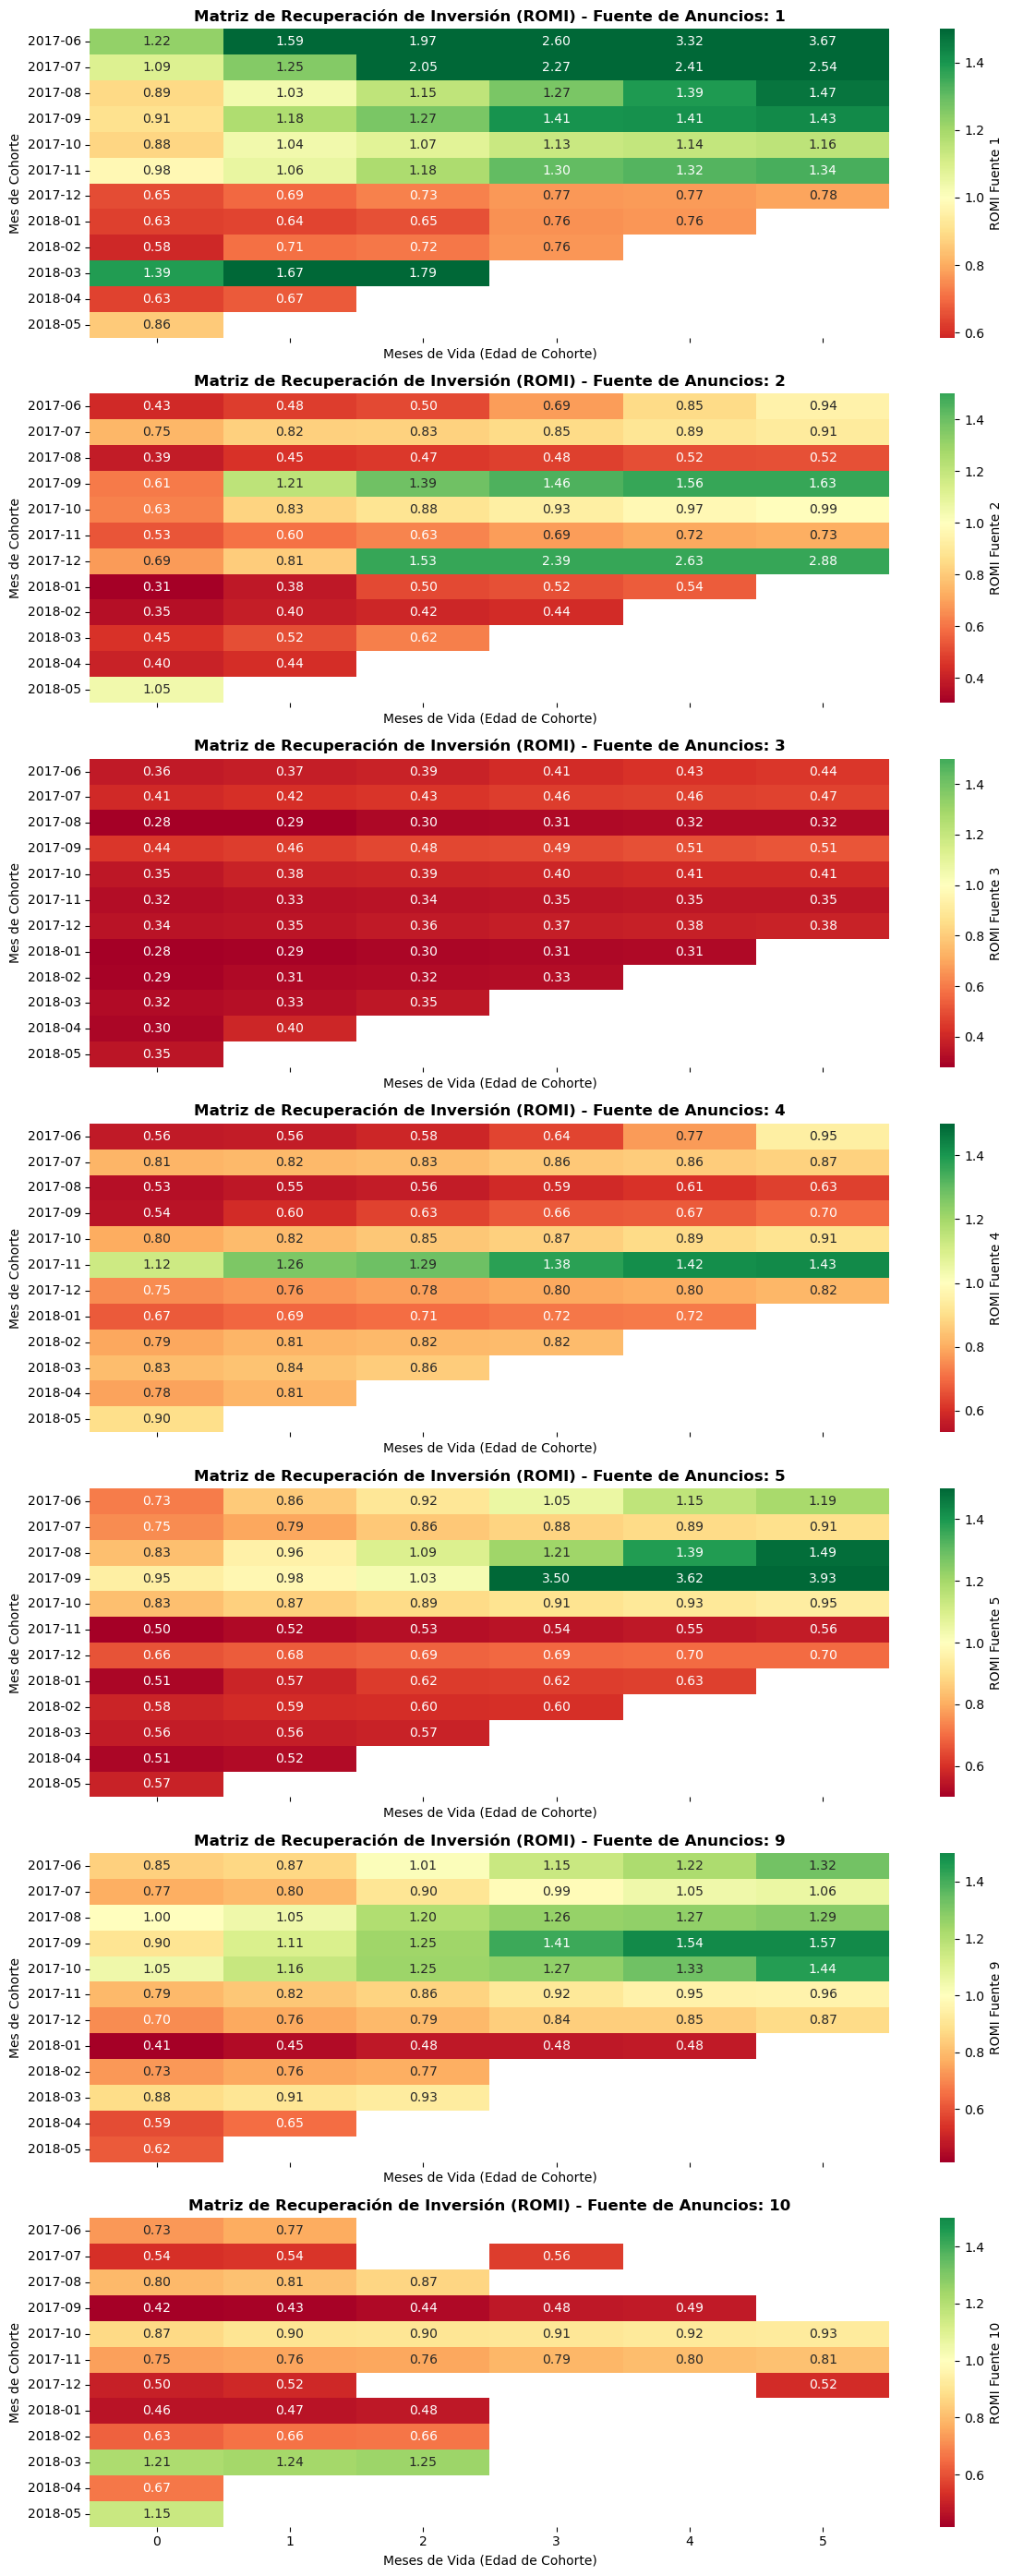

In [51]:
# GENERACIÓN DE MAPAS DE CALOR (HEATMAPS) DEL ROMI POR FUENTE
# ==========================================


# 1. Crear una copia del dataframe maestro y formatear la fecha a texto 'AAAA-MM'
romi_chart_df = romi_master.copy()
romi_chart_df['cohort_month_str'] = romi_chart_df['cohort_month'].dt.strftime('%Y-%m')

# 2. Crear la tabla pivote usando la columna de texto para el eje Y
romi_pivot_source = romi_chart_df.pivot_table(
    index=['source_id', 'cohort_month_str'],
    columns='age',
    values='romi',
    aggfunc='sum'
)

# 3. Identificar las fuentes únicas de anuncios disponibles en los datos comerciales
unique_sources = sorted(romi_master['source_id'].unique())

# 4. Configurar la cuadrícula de gráficos (Subplots dinámicos)
n_sources = len(unique_sources)
fig, axes = plt.subplots(nrows=n_sources, ncols=1, figsize=(12, 4 * n_sources), sharex=True)

# Asegurar que axes sea un arreglo indexable si solo hay una fuente publicitaria
if n_sources == 1:
    axes = [axes]

# 5. CORRECCIÓN: Iterar usando un bloque try/except seguro para evitar problemas de MultiIndex
for i, source in enumerate(unique_sources):
    try:
        # Extraer únicamente los datos de la fuente actual y seleccionar los primeros 6 meses de ciclo de vida (edad 0 a 5)
        source_data = romi_pivot_source.xs(source, level=0).iloc[:, :6]
        
        # Dibujar el heatmap en su respectivo panel
        sns.heatmap(
            source_data, 
            annot=True, 
            fmt=".2f", 
            cmap="RdYlGn",  # Escala de colores semáforo: Rojo (Pérdida) -> Amarillo -> Verde (Rentable)
            vmax=1.5,       # Fijar el tope visual para identificar fácilmente cuándo superan el 1.0 (Punto de equilibrio)
            center=1.0,     # El color amarillo neutro marcará exactamente el punto de equilibrio
            ax=axes[i],
            cbar_kws={'label': f'ROMI Fuente {source}'}
        )
        axes[i].set_title(f'Matriz de Recuperación de Inversión (ROMI) - Fuente de Anuncios: {source}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Mes de Cohorte')
        axes[i].set_xlabel('Meses de Vida (Edad de Cohorte)')
        
    except KeyError:
        # Si una fuente específica no tiene transacciones en el pivote, oculta su panel vacío para que el gráfico quede limpio
        axes[i].axis('off')

plt.tight_layout()
plt.show()

La plataforma cuenta con un flujo promedio estable de usuarios (segmentados en DAU, WAU y MAU según el reporte del Paso 2), sin embargo, el análisis del Sticky Factor y la matriz de Tasa de Retención (Retention Rate) revelan una debilidad estructural: la retención en el Mes 1 cae drásticamente por debajo del 10% para casi todas las cohortes analizadas.

Patrón de Uso: Los usuarios no regresan de manera orgánica ni rutinaria al sitio web. Showz funciona como un servicio puramente transaccional y esporádico; los usuarios ingresan motivados por la compra de entradas para un evento específico y luego abandonan la plataforma.Fricción en el Embudo: La duración típica de una sesión (Moda) es muy corta (cercana a un minuto). Esto nos obliga a mantener un proceso de compra y checkout sumamente ágil y libre de obstáculos.

Velocidad de Conversión: Existe un fenómeno de urgencia publicitaria altamente positivo: el 72% de los usuarios que realizan una compra lo hacen el mismo día de su primer registro (Categoría: Conversion 0d). La mediana de días para convertir es de 0 días, independientemente del dispositivo utilizado. Si un usuario no compra en las primeras 24-48 horas, la probabilidad de conversión cae de forma exponencial.

Evolución de Pedidos en el Tiempo: El volumen histórico de transacciones muestra una clara estacionalidad con picos de venta hacia finales de año. Este volumen está fuertemente dominado por los usuarios de dispositivos Desktop (Escritorio), quienes mantienen una ventaja considerable en transacciones mensuales frente a los usuarios móviles (Touch).

Tamaño Promedio de Compra (Ticket Promedio): Al desglosar el ticket promedio de forma cruzada, los usuarios de Desktop registran un gasto promedio por pedido consistentemente superior al de los usuarios móviles en prácticamente todas las fuentes de anuncios.

Análisis del CAC por Fuente: Tras corregir el sesgo metodológico de población (utilizando estrictamente a los compradores reales como denominador), descubrimos que la Fuente 3 es el canal más ineficiente de la empresa. No solo absorbe el mayor volumen de gasto publicitario, sino que su Costo de Adquisición de Clientes (CAC) experimenta una tendencia alcista alarmante a lo largo del tiempo.

Análisis de Recuperación (ROMI): Nuestro mapa de calor unificado (escala semáforo) demuestra visualmente el éxito financiero de las campañas:Canales Estrella (Fuentes 1, 2 y 5): Presentan un CAC bajo y controlado. El LTV (Valor del Tiempo de Vida del Cliente) acumulado de estas cohortes logra cubrir el costo de adquisición velozmente, alcanzando y superando el punto de equilibrio (ROMI ≥ 1.0) entre el segundo y tercer mes de vida.

Canales Deficitarios (Fuente 3): Permanece congelada en tonalidades rojas y amarillas pálidas. Incluso al llegar al Mes 5 de vida de la cohorte, su ROMI promedio acumulado se mantiene por debajo de 1.0, lo que significa que el dinero invertido en esta plataforma genera pérdidas financieras directas.

A partir de los hallazgos métricos descritos, se aconseja al equipo de marketing implementar de inmediato las siguientes tres acciones:Redirección Inmediata del Presupuesto (¿Dónde y cuánto invertir?):

Es necesario recortar de forma drástica (mínimo un 40%) el presupuesto asignado a la Fuente 3.

Este canal opera a pérdida debido a un CAC inflado que su LTV no logra compensar por lo que reasignar el dinero liberado hacia las Fuentes 1 y 5 es menester. Estas plataformas han demostrado ser los motores de crecimiento más saludables de Showz, devolviendo cada dólar invertido con retornos acelerados antes de los 90 días (ROMI > 1).

Priorización de la Plataforma Comercial (Desktop vs. Móvil):

Se debe enfocar los esfuerzos publicitarios de captación prioritariamente hacia audiencias en dispositivos de Escritorio (Desktop).

Aunque los usuarios móviles convierten igual de rápido (mediana de 0 días), el segmento Desktop genera un volumen de pedidos significativamente mayor y ostenta un ticket promedio superior. Se obtiene un mayor retorno por usuario adquiriendo tráfico de escritorio. (Nota: Paralelamente, se sugiere al equipo de producto optimizar la experiencia de la interfaz móvil para reducir la brecha en el tamaño de compra).

Optimización del Ciclo de Vida y Estrategia del "Día 0":

Se sugiere concentrar el presupuesto de marketing digital en campañas de conversión directa y estrategias de retargeting hiperagresivas durante las primeras 24 horas desde que el usuario se registra.

El 72% de la conversión ocurre el primer día y la retención posterior en los meses 1 a 5 es casi nula. Por lo tanto, no es financieramente viable gastar presupuesto en campañas complejas de fidelización o nutrición de prospectos a largo plazo. Si el usuario no convierte de inmediato, el esfuerzo debe detenerse para maximizar el margen de utilidad.